In [2]:
import openpyxl

def combine_workbooks(workbook1_path, workbook2_path, output_path):
    # Load the workbooks
    wb1 = openpyxl.load_workbook(workbook1_path)
    wb2 = openpyxl.load_workbook(workbook2_path)

    # Create a new workbook for the output
    output_wb = openpyxl.Workbook()
    output_wb.remove(output_wb.active)  # Remove the default sheet

    # Ensure both workbooks have the same number of sheets
    if len(wb1.sheetnames) != len(wb2.sheetnames):
        raise ValueError("Both workbooks must have the same number of sheets.")

    for sheet_name in wb1.sheetnames:
        if sheet_name not in wb2.sheetnames:
            raise ValueError(f"Sheet '{sheet_name}' not found in both workbooks.")

        # Load corresponding sheets
        sheet1 = wb1[sheet_name]
        sheet2 = wb2[sheet_name]

        # Create a new sheet in the output workbook
        output_sheet = output_wb.create_sheet(title=sheet_name)

        # Extract data from both sheets
        data1 = list(sheet1.values)
        data2 = list(sheet2.values)

        # Ensure the sheets have the same number of rows
        if len(data1) != len(data2):
            raise ValueError(f"Sheets '{sheet_name}' have different number of rows.")

        # Combine data row by row
        for row1, row2 in zip(data1, data2):
            # Ensure rows have at least three columns
            if len(row1) < 5 or len(row2) < 5:
                raise ValueError(f"Row in sheet '{sheet_name}' does not have at least three columns.")

            # Combine into six columns
            combined_row = list(row1[:5]) + list(row2[:5])
            output_sheet.append(combined_row)

    # Save the combined workbook
    output_wb.save(output_path)

    wb = openpyxl.load_workbook(output_path)

    # Create a new workbook for the reordered data
    reordered_wb = openpyxl.Workbook()
    reordered_wb.remove(reordered_wb.active)  # Remove the default sheet

    for sheet_name in wb.sheetnames:
        sheet = wb[sheet_name]
        reordered_sheet = reordered_wb.create_sheet(title=sheet_name)

        for row in sheet.iter_rows(values_only=True):
            # Ensure the row has at least 8 columns (pad with None if necessary)
            padded_row = list(row) + [None] * (10 - len(row))

            # Reorder columns: delete column 5, then [2, 6, 3, 7, 4, 8]
            reordered_row = [
                padded_row[0],
                padded_row[1],  # Column 2
                padded_row[6],  # Column 6
                padded_row[2],  # Column 3
                padded_row[7],  # Column 7
                padded_row[3]*105000,  # Column 4
                padded_row[8]*105000,  # Column 8
                padded_row[4],  # Column 4
                padded_row[9]   # Column 8
            ]
            reordered_sheet.append(reordered_row)

    # Save the reordered workbook
    reordered_wb.save(output_path)

# Example usage:
combine_workbooks(r"C:\Users\Tanner\Documents\git\IDAES_MEA_Flowsheet_Tanner\Simulation_Results\Profiles_Implicit_Enhancement_Factor_low_capture.xlsx",
                  r"C:\Users\Tanner\Documents\git\IDAES_MEA_Flowsheet_Tanner\Simulation_Results\Profiles_Explicit_Enhancement_Factor_low_capture.xlsx",
                  r"C:\Users\Tanner\Documents\git\IDAES_MEA_Flowsheet_Tanner\Simulation_Results\combined_low_capture.xlsx")


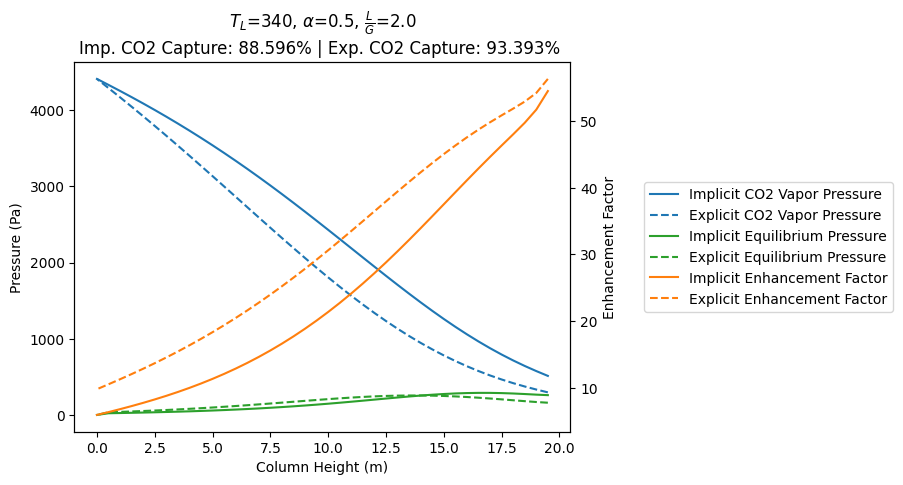

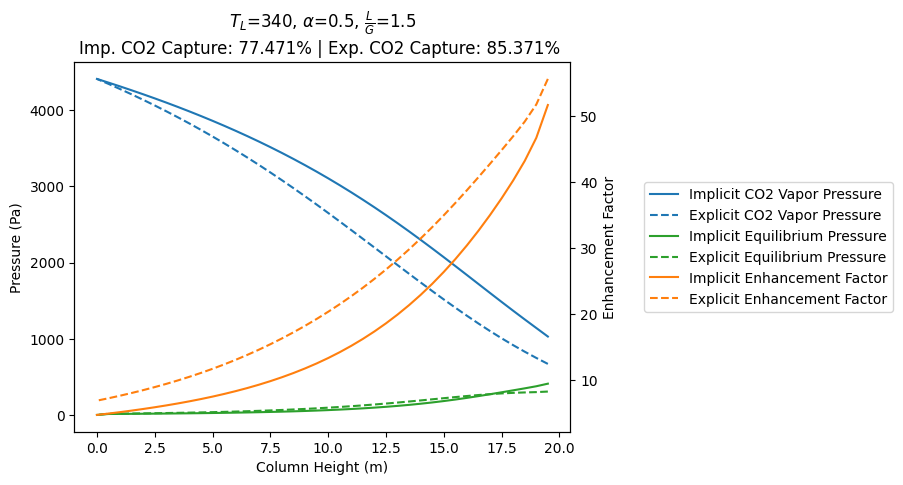

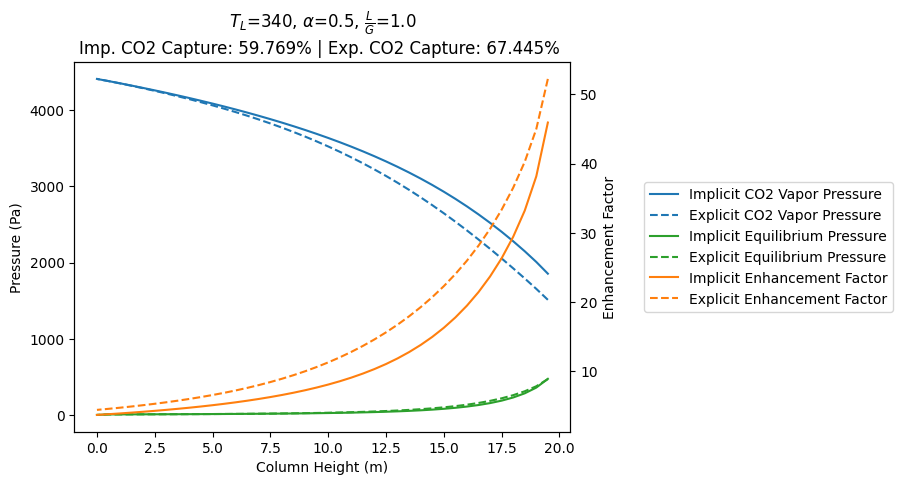

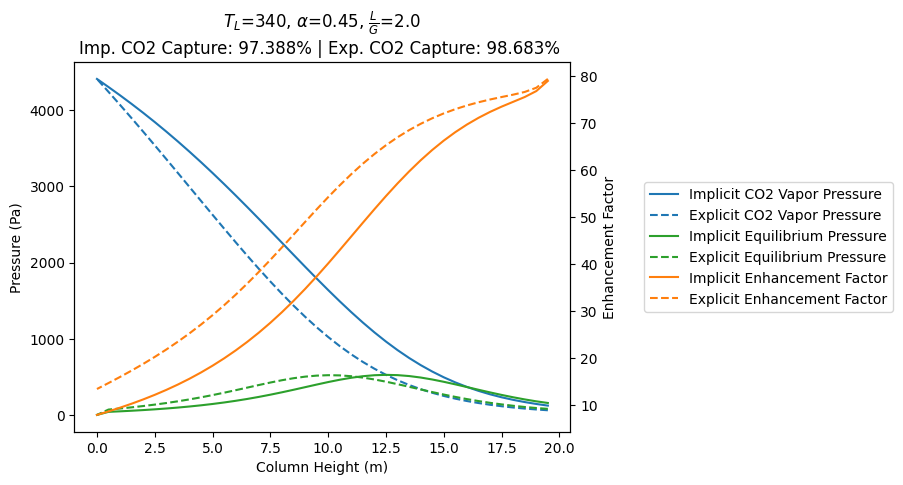

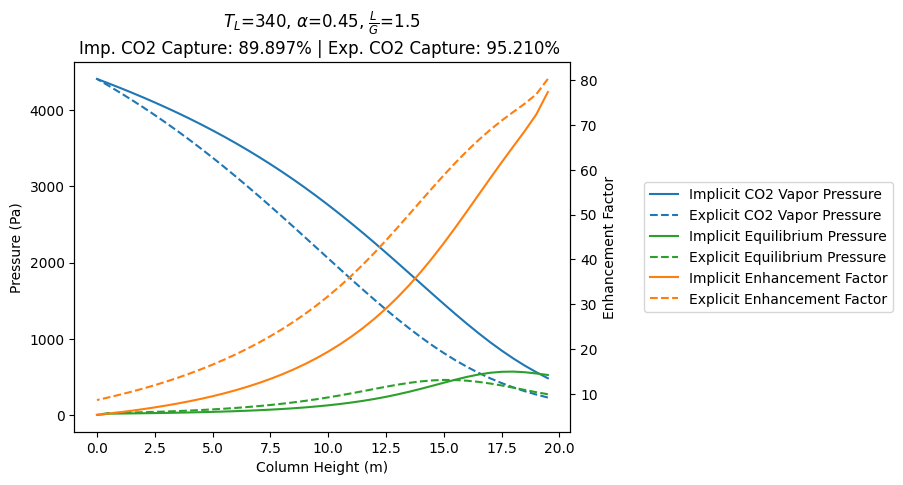

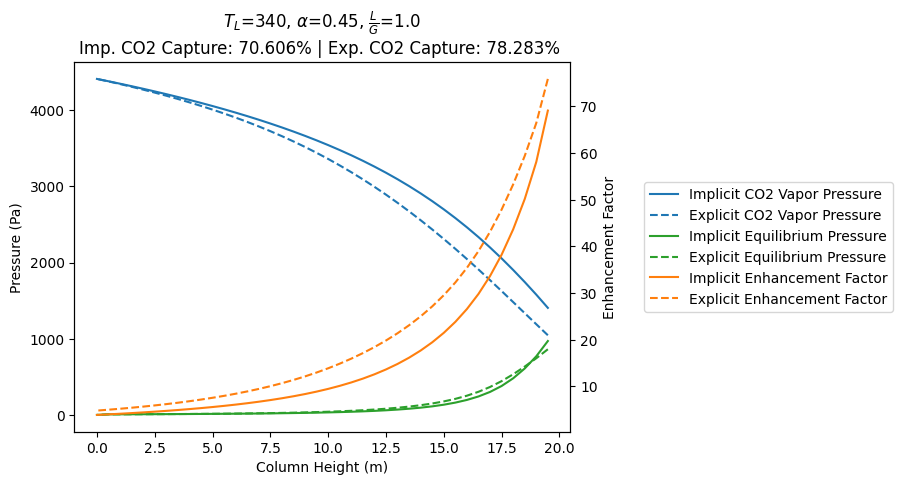

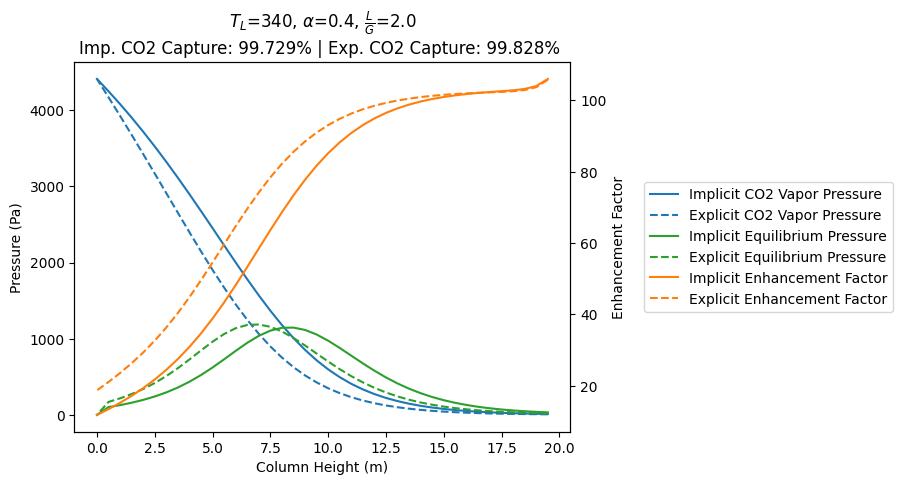

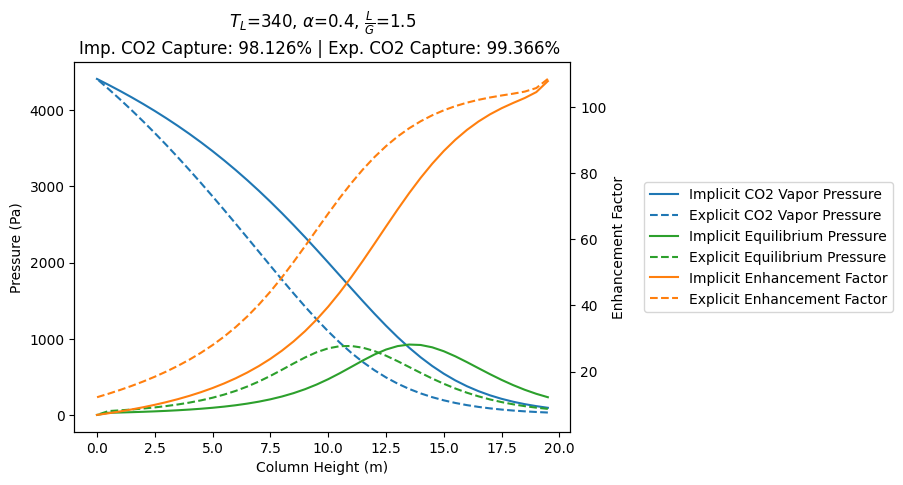

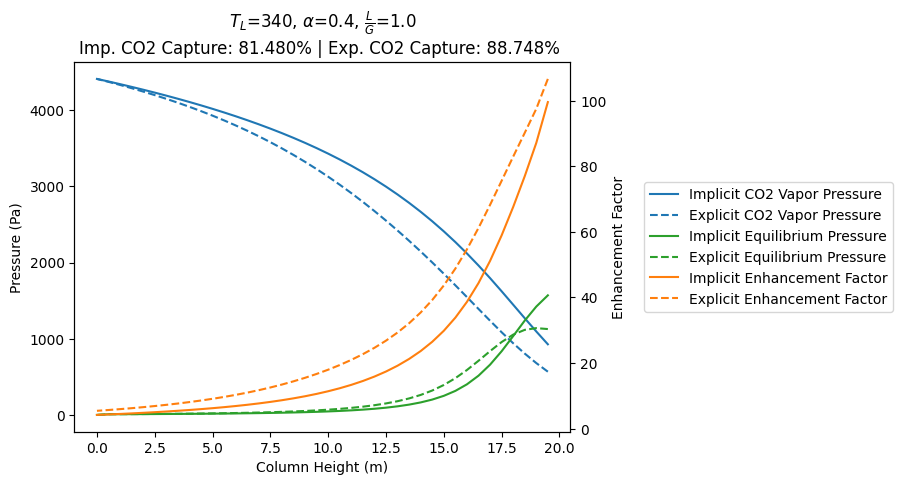

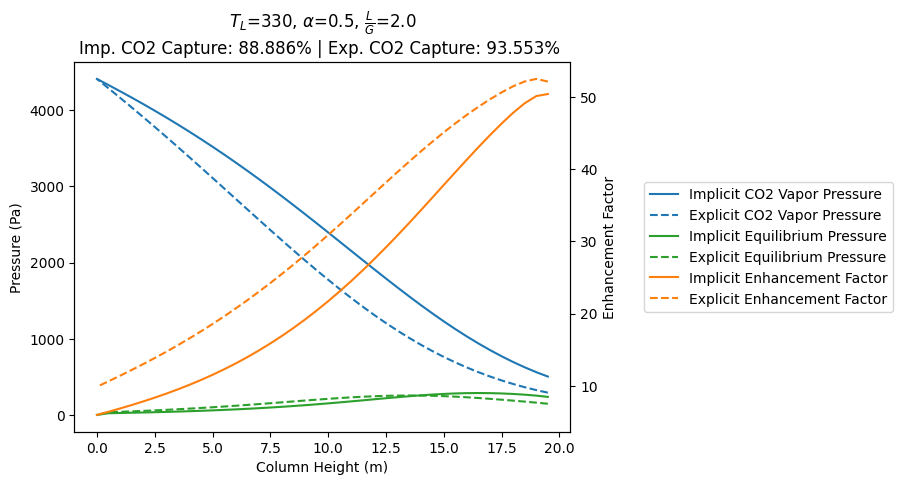

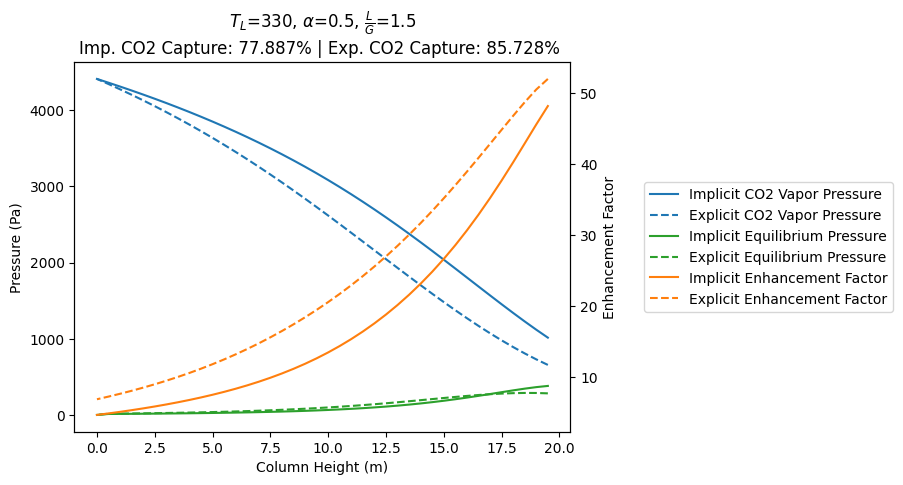

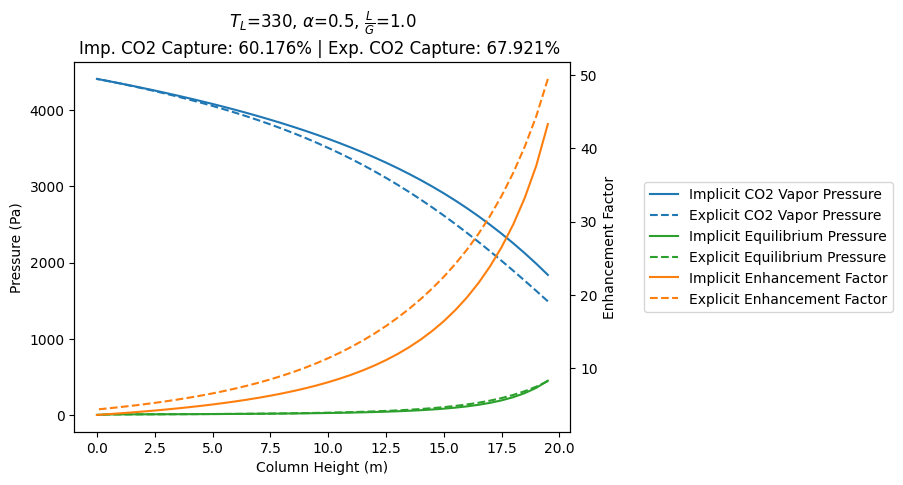

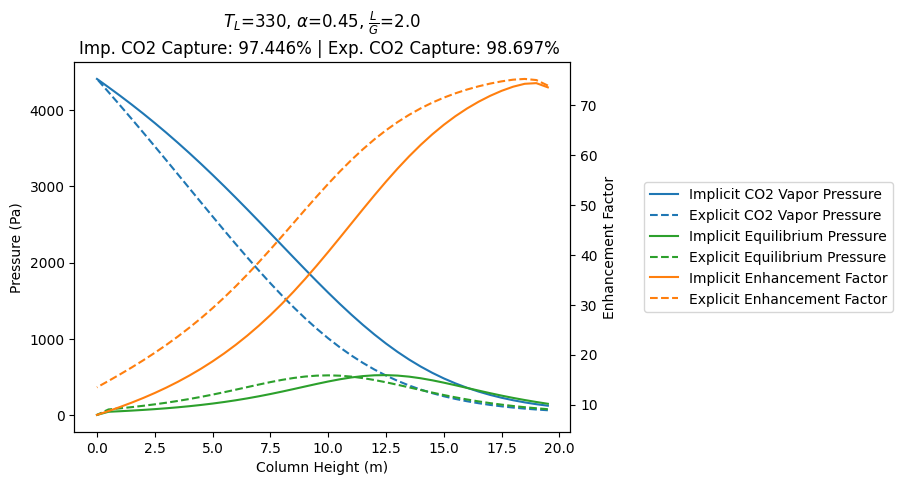

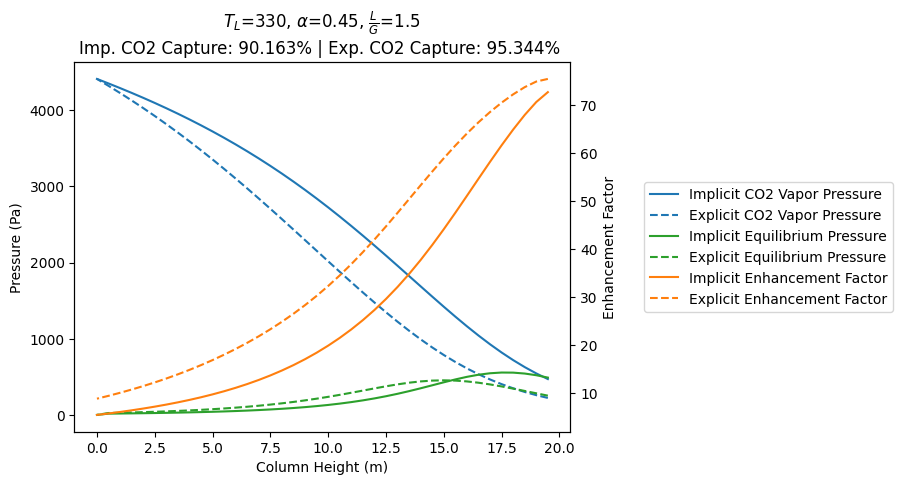

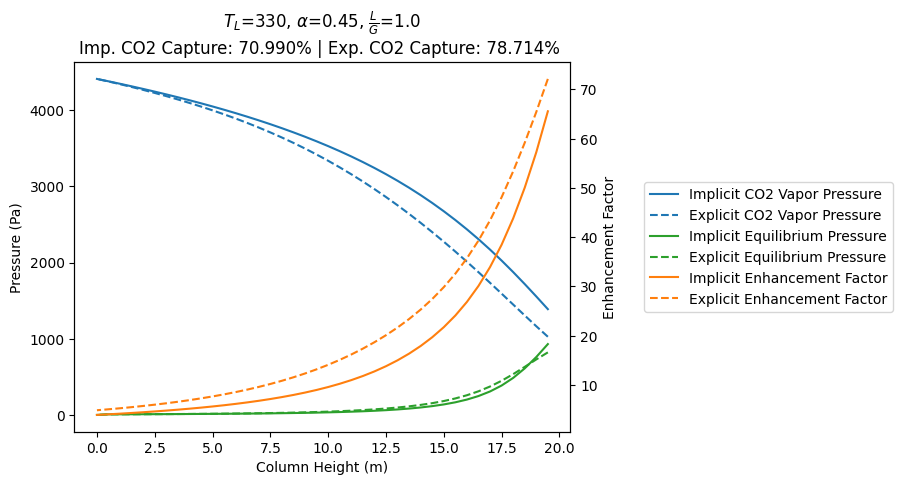

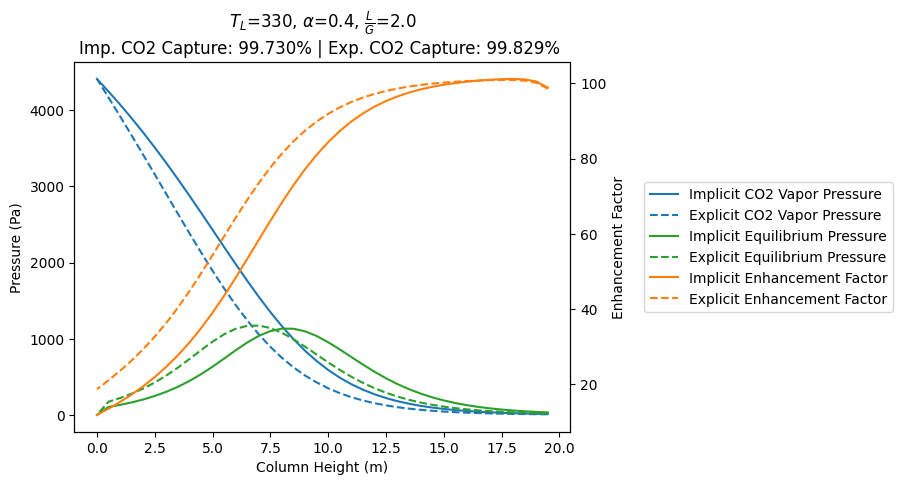

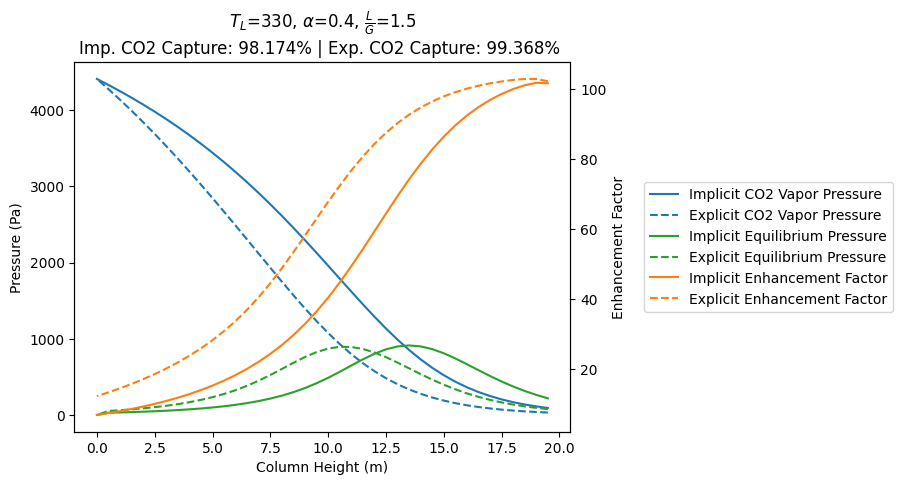

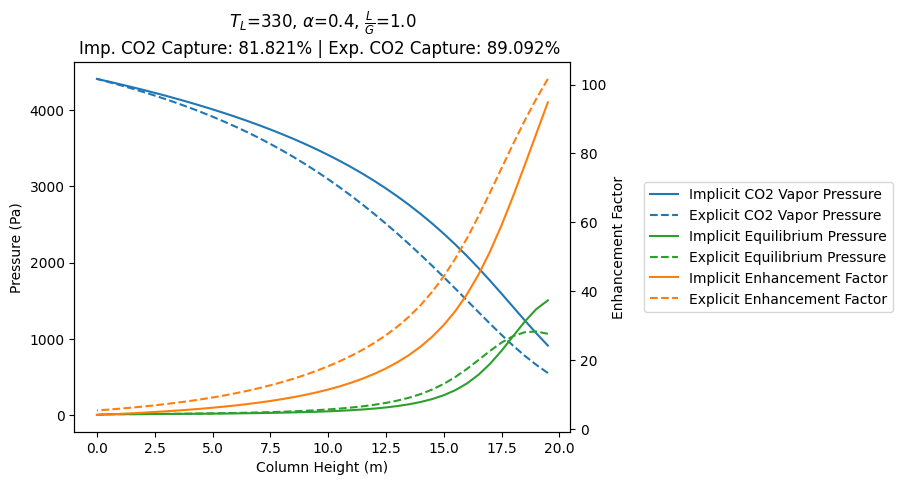

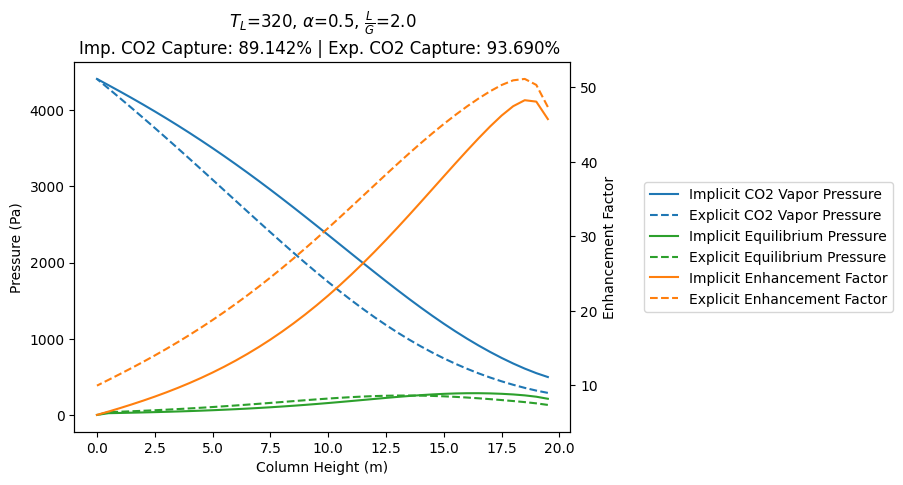

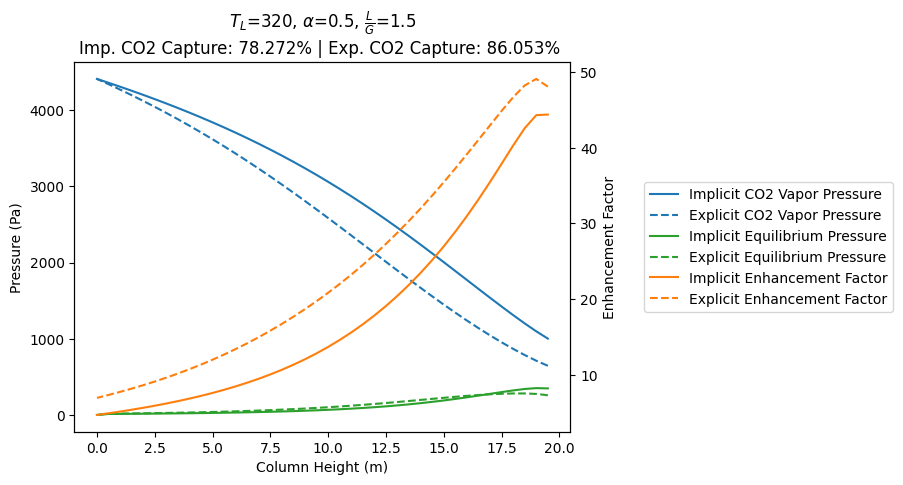

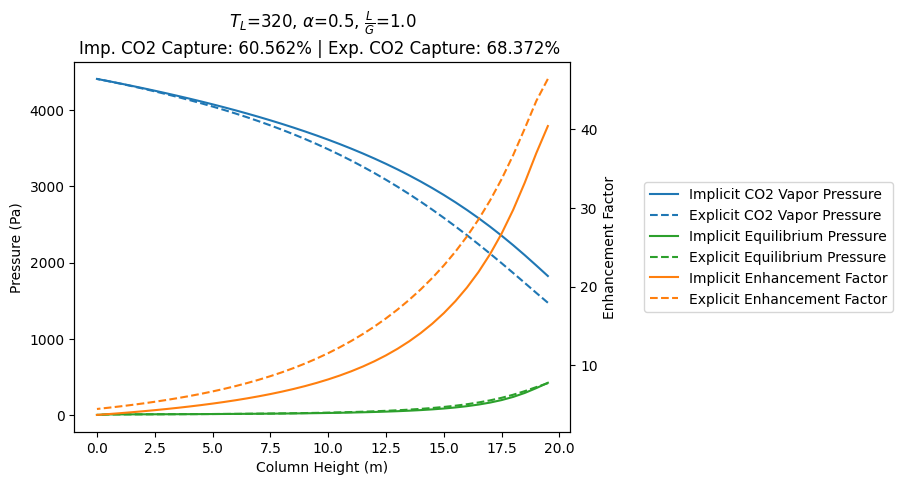

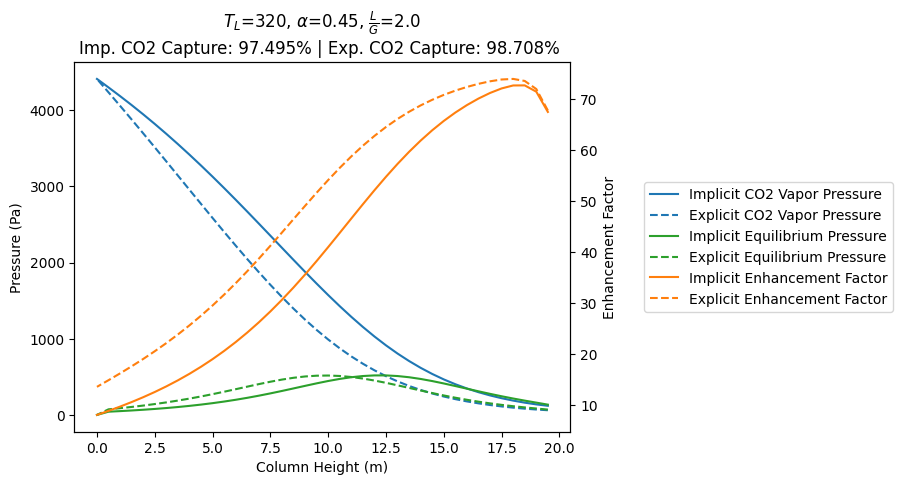

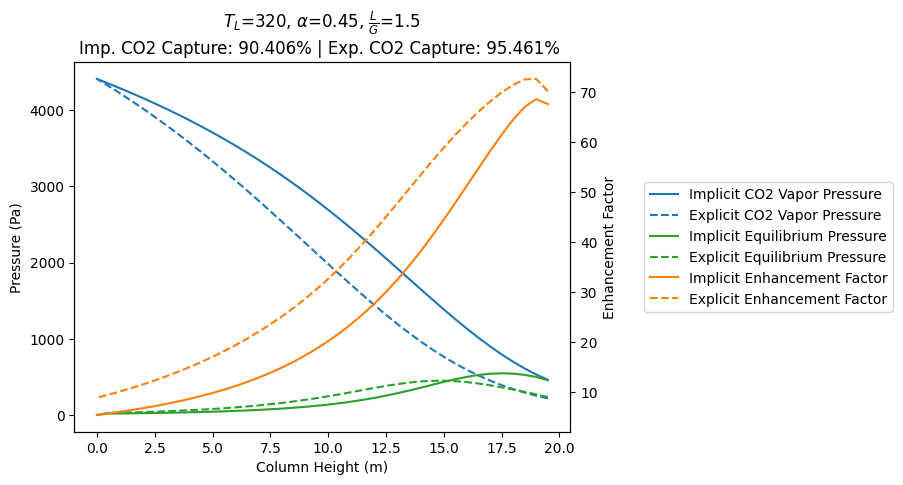

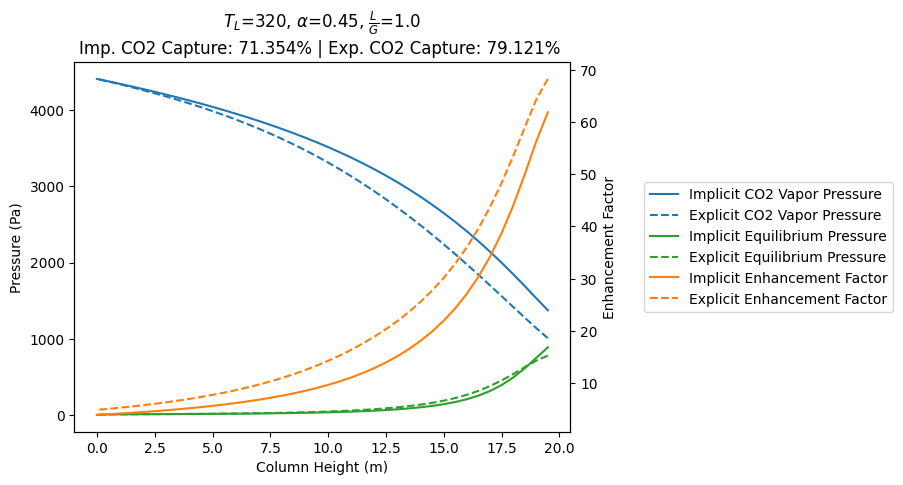

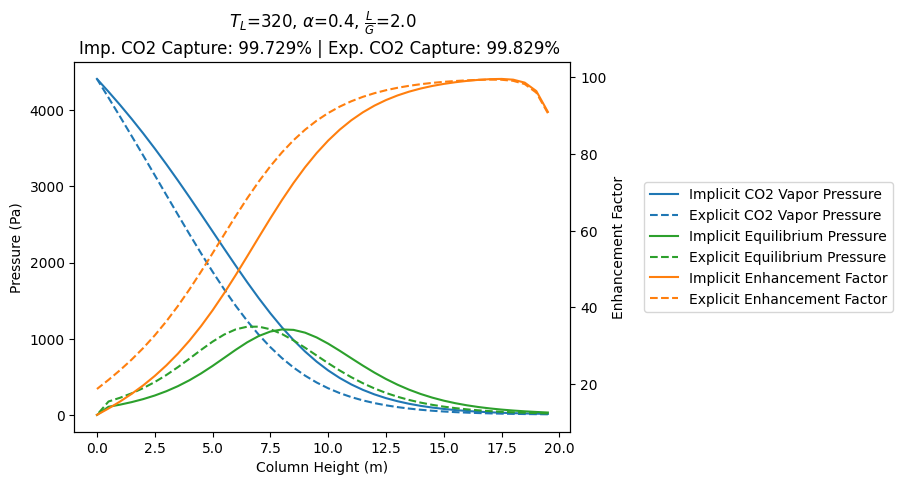

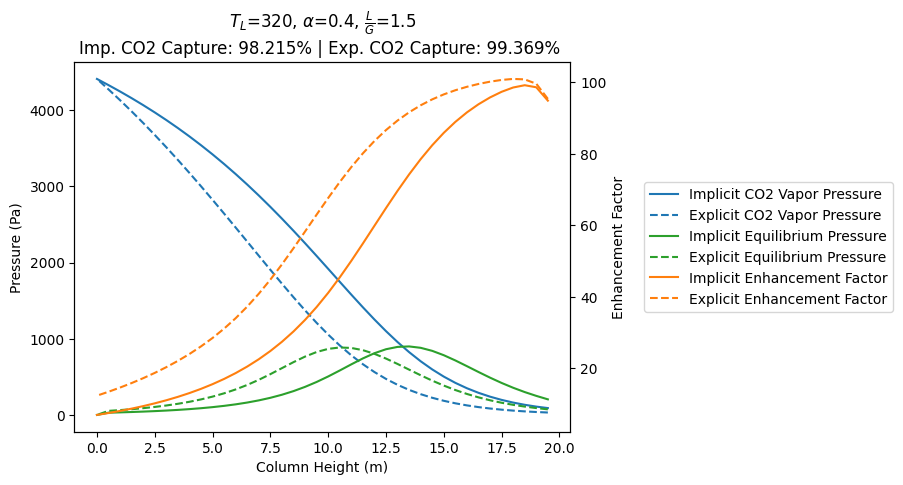

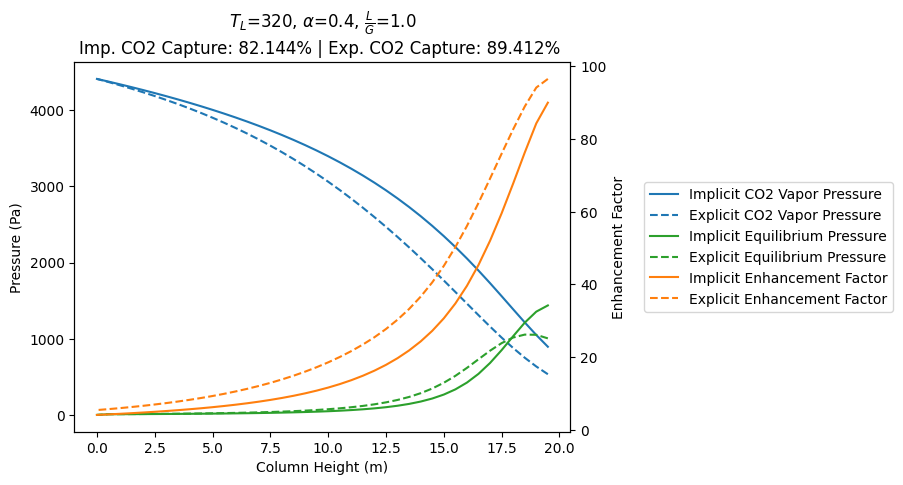

In [3]:
import matplotlib.pyplot as plt

def plot_sheets(workbook_path, output_folder):
    # Load the workbook
    wb = openpyxl.load_workbook(workbook_path, data_only=True)

    for sheet_name in wb.sheetnames:
        sheet = wb[sheet_name]
        data = list(sheet.iter_rows(values_only=True))

        # Extract columns
        x_values = [row[0] for row in data if row[0] is not None][2:]  # Column 1
        E_implicit = [row[1] for row in data if row[1] is not None][2:] # Column 2
        E_explicit = [row[2] for row in data if row[2] is not None][2:]  # Column 3
        P_CO2_implicit = [row[3] for row in data if row[3] is not None][2:] # Column 2
        P_CO2_explicit = [row[4] for row in data if row[4] is not None][2:]  # Column 3
        P_equil_implicit = [row[5] for row in data if row[5] is not None][2:] # Column 2
        P_equil_explicit = [row[6] for row in data if row[6] is not None][2:]  # Column 3

        Tl, alpha, L_G = sheet_name.split(",")
        Tl = Tl[3:]
        alpha = alpha[6:]
        L_G = L_G[5:]

        title = "$T_{L}$=" + Tl + ", " + r"$\alpha$=" + alpha + ", " + r"$\frac{L}{G}$=" + L_G + "\n" + f"Imp. CO2 Capture: {data[1][7]:.3f}% | Exp. CO2 Capture: {data[1][8]:.3f}% "

        # Create the plot
        fig, ax1 = plt.subplots()
        ax1.plot(x_values, P_CO2_implicit, linestyle='-', color='tab:blue', label="Implicit CO2 Vapor Pressure")
        ax1.plot(x_values, P_CO2_explicit, linestyle='--', color='tab:blue', label="Explicit CO2 Vapor Pressure")
        ax1.plot(x_values, P_equil_implicit, linestyle='-', color='tab:green', label="Implicit Equilibrium Pressure")
        ax1.plot(x_values, P_equil_explicit, linestyle='--', color='tab:green', label="Explicit Equilibrium Pressure")
        ax1.set_ylabel("Pressure (Pa)")
        ax1.set_xlabel("Column Height (m)")


        ax2 = ax1.twinx()
        ax2.plot(x_values, E_implicit, linestyle='-', color='tab:orange', label="Implicit Enhancement Factor")
        ax2.plot(x_values, E_explicit, linestyle='--', color='tab:orange', label="Explicit Enhancement Factor")
        ax2.set_ylabel("Enhancement Factor")


        handles, labels = ax1.get_legend_handles_labels()
        handles2, labels2 = ax2.get_legend_handles_labels()
        all_handles = handles + handles2
        all_labels = labels + labels2

        # Create a combined legend
        ax1.legend(all_handles, all_labels, loc="center", bbox_to_anchor=(1.4, .5))

        plt.title(title)

        # Save the plot
        plt.savefig(f"{output_folder}/{sheet_name}.png", bbox_inches="tight")
        # plt.show()
        plt.close()


# Example usage:
# combine_workbooks("workbook1.xlsx", "workbook2.xlsx", "combined_workbook.xlsx")
# reorder_columns("combined_workbook.xlsx", "reordered_workbook.xlsx")
plot_sheets(r"C:\Users\Tanner\Documents\git\IDAES_MEA_Flowsheet_Tanner\Simulation_Results\combined_low_capture.xlsx",
            r"C:\Users\Tanner\Documents\git\IDAES_MEA_Flowsheet_Tanner\Simulation_Results\output_plots_low_capture")

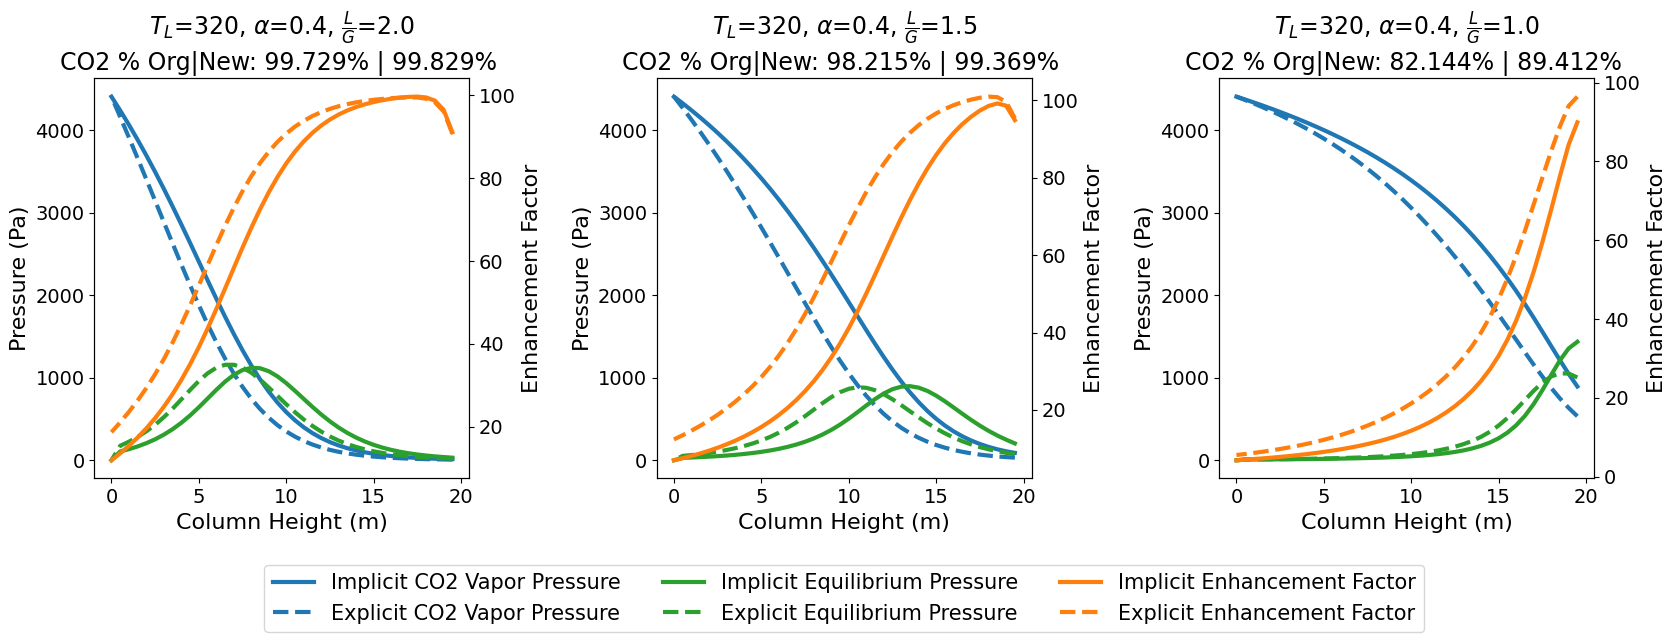

In [114]:
import matplotlib.pyplot as plt

def plot_sheets(workbook_path, output_folder):
    # Load the workbook
    wb = openpyxl.load_workbook(workbook_path, data_only=True)
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    for i, sheet_name in enumerate(wb.sheetnames[-3:]):
        sheet = wb[sheet_name]
        data = list(sheet.iter_rows(values_only=True))

        # Extract columns
        x_values = [row[0] for row in data if row[0] is not None][2:]  # Column 1
        E_implicit = [row[1] for row in data if row[1] is not None][2:] # Column 2
        E_explicit = [row[2] for row in data if row[2] is not None][2:]  # Column 3
        P_CO2_implicit = [row[3] for row in data if row[3] is not None][2:] # Column 2
        P_CO2_explicit = [row[4] for row in data if row[4] is not None][2:]  # Column 3
        P_equil_implicit = [row[5] for row in data if row[5] is not None][2:] # Column 2
        P_equil_explicit = [row[6] for row in data if row[6] is not None][2:]  # Column 3

        Tl, alpha, L_G = sheet_name.split(",")
        Tl = Tl[3:]
        alpha = alpha[6:]
        L_G = L_G[5:]

        title = "$T_{L}$=" + Tl + ", " + r"$\alpha$=" + alpha + ", " + r"$\frac{L}{G}$=" + L_G + "\n" + f"CO2 % Org|New: {data[1][7]:.3f}% | {data[1][8]:.3f}% "

        # Create the plot
        ax[i].plot(x_values, P_CO2_implicit, linestyle='-', color='tab:blue', label="Implicit CO2 Vapor Pressure")
        ax[i].plot(x_values, P_CO2_explicit, linestyle='--', color='tab:blue', label="Explicit CO2 Vapor Pressure")
        ax[i].plot(x_values, P_equil_implicit, linestyle='-', color='tab:green', label="Implicit Equilibrium Pressure")
        ax[i].plot(x_values, P_equil_explicit, linestyle='--', color='tab:green', label="Explicit Equilibrium Pressure")
        ax[i].set_ylabel("Pressure (Pa)")
        ax[i].set_xlabel("Column Height (m)",)
        ax[i].set_title(title)


        ax2 = ax[i].twinx()
        ax2.plot(x_values, E_implicit, linestyle='-', color='tab:orange', label="Implicit Enhancement Factor")
        ax2.plot(x_values, E_explicit, linestyle='--', color='tab:orange', label="Explicit Enhancement Factor")
        ax2.set_ylabel("Enhancement Factor")


    handles, labels = ax[2].get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    all_handles = handles + handles2
    all_labels = labels + labels2

    # Create a combined legend
    ax[2].legend(all_handles, all_labels,
                 loc="center",
                 bbox_to_anchor=(-1, -.3),
                 fontsize=15,
                 ncol=3)

    # Save the plot
    # plt.savefig(f"{output_folder}/{sheet_name}.png", bbox_inches="tight")
    plt.rc('axes', titlesize=17)  # Font size for titles
    plt.rc('axes', labelsize=16)  # Font size for axis labels
    plt.rc('xtick', labelsize=14)  # Font size for x-axis tick labels
    plt.rc('ytick', labelsize=14)  # Font size for y-axis tick labels
    plt.rc('lines', linewidth=3)  # Font size for y-axis tick labels
    plt.subplots_adjust(left=0.0, right=1.0, top=0.9, bottom=0.1, wspace=0.5, hspace=0.5)
    plt.show()
    plt.savefig(r"C:\Users\Tanner\Documents\git\IDAES_MEA_Flowsheet_Tanner\Simulation_Results\plot_comparison.png", bbox_inches='tight' , dpi=500, pad_inches=0.2)
    plt.close()


# Example usage:
# combine_workbooks("workbook1.xlsx", "workbook2.xlsx", "combined_workbook.xlsx")
# reorder_columns("combined_workbook.xlsx", "reordered_workbook.xlsx")
plot_sheets(r"C:\Users\Tanner\Documents\git\IDAES_MEA_Flowsheet_Tanner\Simulation_Results\combined_low_capture.xlsx",
            r"C:\Users\Tanner\Documents\git\IDAES_MEA_Flowsheet_Tanner\Simulation_Results\output_plots_low_capture")

In [4]:
import os
import zipfile
from pptx import Presentation
from pptx.util import Inches

def create_slide_deck(extraction_directory, output_pptx_path):
    # Create a temporary directory to extract the images

    # Locate image files
    image_files = []
    for root, dirs, files in os.walk(extraction_directory):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.gif')):
                image_files.append(os.path.join(root, file))

    # Create a PowerPoint presentation
    presentation = Presentation()

    # Add each image to the presentation without a title
    for image_file in image_files:
        slide = presentation.slides.add_slide(presentation.slide_layouts[6])  # Blank slide layout
        slide.shapes.add_picture(image_file, Inches(1), Inches(1), width=Inches(8))

    # Save the PowerPoint presentation
    presentation.save(output_pptx_path)
    print(f"Slide deck created: {output_pptx_path}")

zip_file = r"C:\Users\Tanner\Documents\git\IDAES_MEA_Flowsheet_Tanner\Simulation_Results\output_plots_low_capture"
output_pptx = r"C:\Users\Tanner\Documents\git\IDAES_MEA_Flowsheet_Tanner\Simulation_Results\Enhancement_plots_low_capture.pptx"
create_slide_deck(zip_file, output_pptx)

Slide deck created: C:\Users\Tanner\Documents\git\IDAES_MEA_Flowsheet_Tanner\Simulation_Results\Enhancement_plots_low_capture.pptx


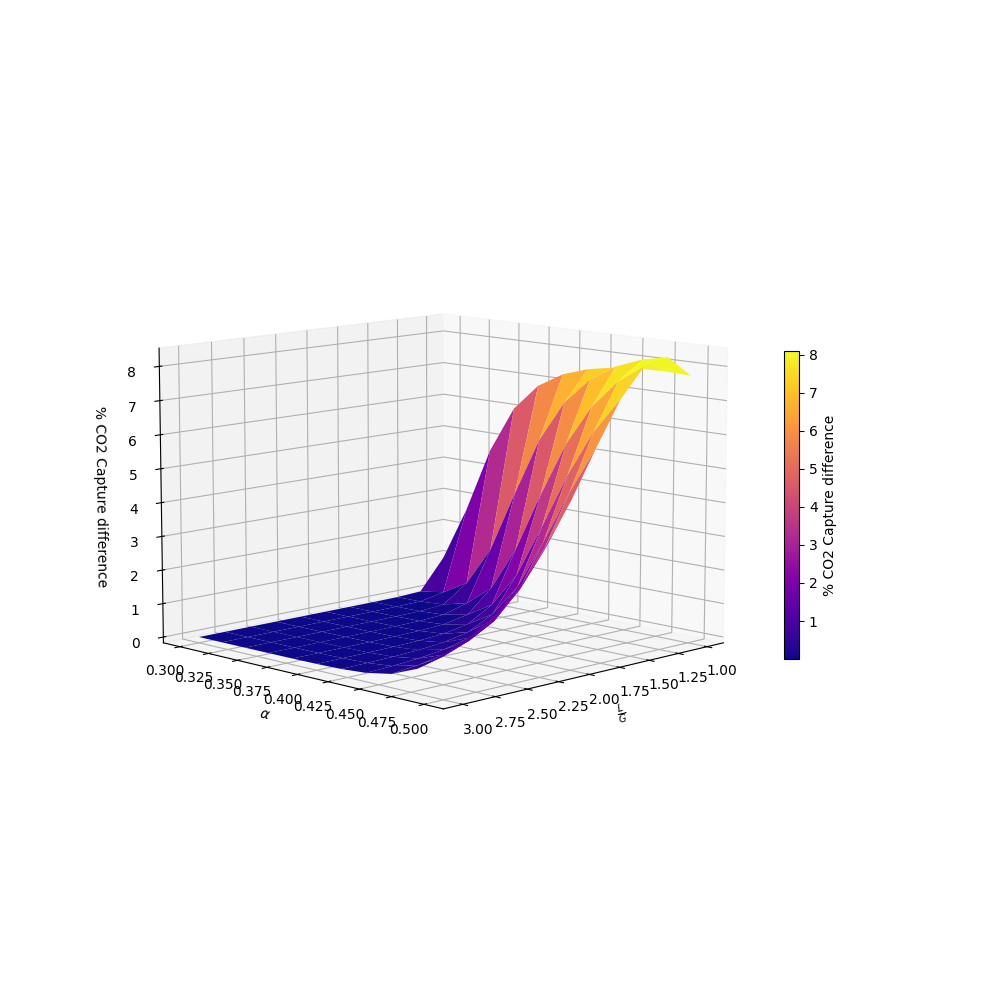

In [11]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def plot_sheets():
    # Load the workbook
    df = pd.read_csv(r"C:\Users\Tanner\Documents\git\IDAES_MEA_Flowsheet_Tanner\Simulation_Results\surface_data_implicit.csv")
    df2 = pd.read_csv(r"C:\Users\Tanner\Documents\git\IDAES_MEA_Flowsheet_Tanner\Simulation_Results\surface_data_explicit.csv")
    L_G_list = df['L/G'].unique()
    alpha_list = df['alpha'].unique()
    CO2_imp = df['CO2_capture'].to_numpy()
    CO2_exp = df2['CO2_capture'].to_numpy()
    X, Y = np.meshgrid(L_G_list, alpha_list)
    Z1 = CO2_imp.reshape((11, 11))
    Z2 = CO2_exp.reshape((11, 11))
    diff_magnitude = np.abs(Z1 - Z2)

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    # ax.plot_surface(X, Y, Z1, alpha=1, label='Original')  # Use a colormap like 'viridis'
    # ax.plot_surface(X, Y, Z2, alpha=.5, label='Reformulated')  # Use a colormap like 'viridis'
    surf = ax.plot_surface(X, Y, diff_magnitude, cmap='plasma')
    ax.set_xlabel(r"$\frac{L}{G}$")
    ax.set_ylabel(r"$\alpha$")
    ax.set_zlabel("% CO2 Capture difference")
    ax.view_init(elev=10, azim=45)
    cbar = fig.colorbar(surf, shrink=.4)  # Add a color bar
    cbar.set_label("% CO2 Capture difference")
    # plt.legend()
    plt.show()


# Example usage:
# combine_workbooks("workbook1.xlsx", "workbook2.xlsx", "combined_workbook.xlsx")
# reorder_columns("combined_workbook.xlsx", "reordered_workbook.xlsx")
%matplotlib widget
plot_sheets()